# Cross-modal integration: LINCS Cell Painting morphology vs. scRNA-seq (A549)

This is the LINCS counterpart to `morphology_expression_integration.ipynb`
(HepG2 + a bioactive-compound morphology library). Same question, different
dataset: does Cell Painting morphology agree with single-cell transcriptomics
on which compounds resemble each other, using the Broad LINCS pilot data
(A549 lung cancer cells, Drug Repurposing Hub library) instead of the HepG2
multi-site bioactives screen?

**Expression**: `LINCS/a549_cells.h5ad` - single-cell RNA-seq of A549 cells
(605,940 cells x 62,710 genes) treated with 94 small molecules, annotated
with `drug` and a coarse `moa-fine` label (23 classes). Same shape/schema as
`hepg2_cells.h5ad` in the sibling notebook (no dose annotation - cells for a
drug are pooled across whatever doses/samples were profiled).

**Morphology**: `LINCS/morphology/` is a local checkout of the
[`broadinstitute/lincs-cell-painting`](https://github.com/broadinstitute/lincs-cell-painting)
repo, which defines five Cell Painting data levels. The repo covers two A549
batches; this notebook uses `2016_04_01_a549_48hr_batch1` (a fixed-48h
screen), which is where all 94/94 of `a549_cells.h5ad`'s drugs are found in
the compound library actually used (see section 7 for how they're matched -
by PubChem CID chemical identity, a perfect match; a plain compound-name
match only found 86/94).

| Level | Description | Suffix |
| :--- | :--- | :--- |
| 3 | Per-well aggregated + annotated profiles | `_augmented.csv.gz` |
| 4a | Normalized (z-scored per plate) | `_normalized.csv.gz` |
| 4b | Normalized + feature-selected | `_normalized_feature_select.csv.gz` |
| 5 | Consensus perturbation signatures (median / MODZ) | `_consensus_{median,modz}[_feature_select].csv.gz` |

**Data-availability note.** `LINCS/morphology/profiles/` (levels 3/4a/4b) is
tracked with `dvc` against a private S3 remote, and `LINCS/morphology/consensus/`
(level 5) is tracked with `git lfs` - neither had actually been pulled
locally (the profiles directory only held `.dvc` pointer files, and every
consensus `.csv.gz` was a 133-byte git-lfs pointer stub, not real data), and
neither `dvc` nor `git-lfs` nor S3 credentials for that remote were available
in this environment. Both are recovered here from public mirrors instead:

- Levels 3/4a/4b: the same per-plate files are also public, unauthenticated,
  on the [Cell Painting Gallery](https://github.com/broadinstitute/cellpainting-gallery)
  AWS Open Data bucket (`s3://cellpainting-gallery/cpg0004-lincs/...`). All
  136 batch1 plates' `_augmented.csv.gz` (level 3) were downloaded from
  there into `LINCS/morphology/profiles/<batch>/<plate>/`, plus one
  reference plate's official `_normalized.csv.gz` /
  `_normalized_feature_select.csv.gz` for validation below.
- Level 5: this repo's own `.csv.gz` files are git-lfs pointers into
  `github.com`, which serves lfs objects publicly and unauthenticated via
  `media.githubusercontent.com` - fetched directly and checksummed against
  the pointer's `sha256`/`size` before overwriting the stub files in place.

Given that, this notebook does something the HepG2 one didn't need to: it
**reconstructs levels 4a and 4b from level 3 itself** (same `pycytominer`
calls the repo's own `profile_cells.py` uses) and validates the
reconstruction at every step against Broad's official precomputed files -
the single reference plate for 4a/4b, and the real level-5 consensus files
for the final consensus step. That reconstruction is also what feeds the
expression-integration analysis below, so the two notebooks stay
methodologically parallel (pool wells -> normalize per plate -> feature-select
once, pooled -> average into one profile per compound), rather than just
swapping in Broad's premade consensus file directly.


In [1]:
import glob
import os
import re
import warnings
from itertools import combinations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]

BATCH1 = "2016_04_01_a549_48hr_batch1"  # fixed 48h treatment
MORPH_DIR = "LINCS/morphology"
COMPARTMENTS = ["Cells", "Nuclei", "Cytoplasm"]
FEATURE_SELECT_OPS = ["variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist"]


## 1. Load gene expression

Raw UMI counts, `drug` / `moa-fine` as
per-cell categoricals, no vehicle/DMSO control group and no per-cell dose
annotation.


In [2]:
rna = ad.read_h5ad("LINCS/a549_cells.h5ad")
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


605940 cells x 62710 genes
94 drugs, 14 plates, 23 moa-fine classes, cell line ['CVCL_0023']


,n_cells,moa_fine
drug,,
Dinaciclib,1085,CDK inhibitor
Cobimetinib,2499,MEK inhibitor
Menadione,2593,unclear
Hydroxyurea,2730,DNA synthesis/repair inhibitor
Clofarabine,2928,DNA synthesis/repair inhibitor


## 2. Morphology: load Level 3 (batch 1) and reproduce Level 4a

Batch 1 (`2016_04_01_a549_48hr_batch1`) is the fixed-48h screen used as the
morphology dataset below. All 136 plates' `_augmented.csv.gz`
(Level 3: per-well aggregated profiles + platemap/MoA annotation, joined by
`profile_cells.py` at acquisition time) are pooled, then normalized per
plate with the same call `profile_cells.py` uses
(`mad_robustize`, `samples="all"` i.e. whole-plate, not DMSO-only) to
reproduce Level 4a.

Validated against Broad's official Level 4a for one reference plate
(`SQ00014812`, downloaded separately): per-feature correlation between our
reproduction and the official file is effectively 1.0 - confirming the
reconstruction uses the same normalization Broad used, not just something
similar.


In [3]:
def load_level3_plate(f):
    d = pd.read_csv(f)
    feat_cols = [c for c in d.columns if not c.startswith("Metadata_")]
    d = d.astype({c: "float32" for c in feat_cols})
    plate = os.path.basename(os.path.dirname(f))
    return d.assign(Metadata_SourceFile=plate)


def normalize_per_plate(df, features):
    parts = [
        normalize(group, features=features, meta_features="infer", samples="all", method="mad_robustize")
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


level3_files = sorted(glob.glob(f"{MORPH_DIR}/profiles/{BATCH1}/*/*_augmented.csv.gz"))
print(f"batch1: {len(level3_files)} Level 3 plate files")

level3_batch1 = pd.concat([load_level3_plate(f) for f in level3_files], ignore_index=True)
CP_FEATURES_BATCH1 = infer_cp_features(level3_batch1, compartments=COMPARTMENTS)
print(f"{level3_batch1.shape[0]} wells x {len(CP_FEATURES_BATCH1)} inferred CP features (Level 3)")

level4a_batch1 = normalize_per_plate(level3_batch1, CP_FEATURES_BATCH1)
print(f"Level 4a (reproduced): {level4a_batch1.shape}")


batch1: 136 Level 3 plate files


52223 wells x 1781 inferred CP features (Level 3)


Level 4a (reproduced): (52223, 1811)


In [4]:
# Validate the Level 4a reproduction against Broad's official file for one reference plate.
REFERENCE_PLATE_BATCH1 = "SQ00014812"
official_4a = pd.read_csv(f"{MORPH_DIR}/profiles_reference/{REFERENCE_PLATE_BATCH1}_normalized.csv.gz")
ours_4a = (
    level4a_batch1[level4a_batch1["Metadata_SourceFile"] == REFERENCE_PLATE_BATCH1]
    .sort_values("Metadata_Well").reset_index(drop=True)
)
official_4a = official_4a.sort_values("Metadata_Well").reset_index(drop=True)

wells_match = (ours_4a["Metadata_Well"].to_numpy() == official_4a["Metadata_Well"].to_numpy()).all()
shared_feats = [f for f in CP_FEATURES_BATCH1 if f in official_4a.columns]
corrs = np.array([np.corrcoef(ours_4a[f], official_4a[f])[0, 1] for f in shared_feats[:200]])

print(f"Reference plate {REFERENCE_PLATE_BATCH1}: wells aligned = {wells_match}")
print(f"Per-feature correlation (our Level 4a vs. Broad's official Level 4a, 200-feature sample): "
      f"median={np.nanmedian(corrs):.6f}, mean={np.nanmean(corrs):.6f}")


Reference plate SQ00014812: wells aligned = True
Per-feature correlation (our Level 4a vs. Broad's official Level 4a, 200-feature sample): median=1.000000, mean=1.000000


## 3. Reproduce Level 4b (feature selection)

Same feature-selection operations `profile_cells.py` uses
(`variance_threshold`, `correlation_threshold`, `drop_na_columns`,
`blocklist`), applied once to the pooled 136-plate batch - not per plate -
so all plates share one feature space, mirroring how the HepG2 notebook
pools all sites before feature-selecting once.

That pooled-vs-per-plate difference is exactly why this doesn't reproduce
Broad's official per-plate Level 4b file feature-for-feature; the overlap
below (~80%) is the expected signature of that deliberate methodological
choice, not a bug.


In [5]:
level4b_batch1 = feature_select(level4a_batch1, features=CP_FEATURES_BATCH1, operation=FEATURE_SELECT_OPS)
morph_feature_cols_batch1 = [c for c in level4b_batch1.columns if not c.startswith("Metadata_")]
print(f"Level 4b (reproduced, pooled feature selection): {len(morph_feature_cols_batch1)} features, "
      f"{level4b_batch1.shape[0]} wells")

official_4b = pd.read_csv(f"{MORPH_DIR}/profiles_reference/{REFERENCE_PLATE_BATCH1}_normalized_feature_select.csv.gz")
official_4b_feats = [c for c in official_4b.columns if not c.startswith("Metadata_")]
overlap = set(morph_feature_cols_batch1) & set(official_4b_feats)
print(f"Broad's official per-plate Level 4b for {REFERENCE_PLATE_BATCH1}: {len(official_4b_feats)} features")
print(f"Overlap with our pooled-batch Level 4b: {len(overlap)}/{len(official_4b_feats)}")


Level 4b (reproduced, pooled feature selection): 615 features, 52223 wells
Broad's official per-plate Level 4b for SQ00014812: 493 features
Overlap with our pooled-batch Level 4b: 400/493


## 4. Well-level QC: percent replicating & leave-one-out

Same two checks as the HepG2 notebook's consensus-aggregation section, but
run here on Level 4b directly (replicate wells = same `Metadata_broad_sample`
**and** `Metadata_dose_recode`, since this library spans up to 7 dose
points per compound - unlike HepG2's single-dose bioactives). Pairwise
correlations are computed via row z-scoring + dot product rather than a full
`n_wells x n_wells` correlation matrix, since pooling all 136 plates gives
~52k wells (a dense correlation matrix at that size doesn't fit in memory).


In [6]:
level4b_batch1 = level4b_batch1.dropna(subset=morph_feature_cols_batch1).reset_index(drop=True)
level4b_batch1["Metadata_group"] = (
    level4b_batch1["Metadata_broad_sample"] + "__" + level4b_batch1["Metadata_dose_recode"].astype(str)
)
non_dmso_batch1 = level4b_batch1[level4b_batch1["Metadata_broad_sample"] != "DMSO"].reset_index(drop=True)

X = non_dmso_batch1[morph_feature_cols_batch1].to_numpy(dtype=np.float64)
Xz = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True, ddof=0)
n_feat = Xz.shape[1]


def corr_pair(i, j):
    return np.dot(Xz[i], Xz[j]) / n_feat


groups = non_dmso_batch1["Metadata_group"].to_numpy()
doses = non_dmso_batch1["Metadata_dose_recode"].to_numpy()
group_to_idx = {}
for i, g in enumerate(groups):
    group_to_idx.setdefault(g, []).append(i)
group_sizes = {g: len(v) for g, v in group_to_idx.items()}
group_dose = {g: doses[v[0]] for g, v in group_to_idx.items()}
replicated_groups = [g for g, n in group_sizes.items() if n >= 2]

rng = np.random.RandomState(RANDOM_STATE)
replicate_corr = pd.Series({
    g: np.median([corr_pair(i, j) for i, j in combinations(group_to_idx[g], 2)])
    for g in replicated_groups
})

all_idx = np.arange(len(non_dmso_batch1))
n_null = 1000
null_medians = np.empty(n_null)
for it in range(n_null):
    g = rng.choice(replicated_groups)
    k = group_sizes[g]
    g_idx_set = set(group_to_idx[g])
    other_idx = np.array([i for i in all_idx if i not in g_idx_set])
    sample = rng.choice(other_idx, size=k, replace=False)
    null_medians[it] = np.median([corr_pair(i, j) for i, j in combinations(sample, 2)])

threshold = np.percentile(null_medians, 95)
pct_replicating = (replicate_corr > threshold).mean()
print(f"Percent replicating (compound-dose groups, batch1, non-DMSO): {pct_replicating:.1%}")
print(f"  null 95th percentile r={threshold:.3f}, median replicate r={replicate_corr.median():.3f}, "
      f"n={len(replicate_corr)} groups")

dose_of_group = pd.Series(group_dose)
for lo, hi, label in [(1, 2, "low dose (1-2)"), (3, 4, "mid dose (3-4)"), (5, 7, "high dose (5-7)")]:
    mask = dose_of_group.reindex(replicate_corr.index).between(lo, hi)
    sub = replicate_corr[mask]
    print(f"  {label}: n={len(sub)}, pct_replicating={(sub > threshold).mean():.1%}, median r={sub.median():.3f}")


Percent replicating (compound-dose groups, batch1, non-DMSO): 37.4%
  null 95th percentile r=0.014, median replicate r=0.003, n=9394 groups
  low dose (1-2): n=3136, pct_replicating=34.9%, median r=0.002
  mid dose (3-4): n=3136, pct_replicating=35.9%, median r=0.003
  high dose (5-7): n=3122, pct_replicating=41.5%, median r=0.005


In [7]:
agreements = []
for g in replicated_groups:
    idxs = group_to_idx[g]
    Xg = X[idxs]
    for i in range(len(idxs)):
        loo_mean = (Xg.sum(axis=0) - Xg[i]) / (len(idxs) - 1)
        agreements.append(np.corrcoef(Xg[i], loo_mean)[0, 1])
agreements = np.array(agreements)

print("Leave-one-out check: correlation between each replicate well and the mean of its\n"
      "OTHER replicates (excluding itself).\n")
print(f"mean r={np.nanmean(agreements):.3f}, median r={np.nanmedian(agreements):.3f} (n={len(agreements)} wells)")


Leave-one-out check: correlation between each replicate well and the mean of its
OTHER replicates (excluding itself).

mean r=0.223, median r=0.004 (n=48958 wells)


**Result**: 37.4% percent replicating overall, with a clear dose-response
gradient (34.9% at low doses -> 41.5% at high doses) - weaker than the HepG2
notebook's 69-91% because this is a much more heterogeneous compound-dose
combination (the full ~1500-compound Drug Repurposing library at up to 7
doses, most of them well below any effective concentration for a given
compound), not a curated bioactives-at-effective-dose panel. The
mean/median leave-one-out gap (0.223 vs. 0.004) says the same thing a
different way: a minority of compound-dose combinations reproduce very
well, the majority show little-to-no morphological phenotype at all,
consistent with "most (compound, dose) pairs on this plate design don't do
much to the cells."


## 5. Phenotypic activity vs. negative controls (copairs mAP)

Percent replicating (section 4) asks whether a compound-dose group's
replicate wells agree with *each other* more than with random other wells.
The complementary, standard image-based-profiling check is **mean average
precision (mAP) against negative controls**: can a compound-dose group's
replicate wells be told apart from actual untreated DMSO wells at all, not
just from other treatments. `copairs` (the package behind the JUMP Cell
Painting consortium's activity calls) computes this directly, with a
permutation null and Benjamini-Hochberg FDR correction per compound-dose
group.

Computed on the full pooled batch1 Level 4b data (136 plates, DMSO wells
included), grouped by the same `Metadata_group` (compound x dose) used for
percent replicating above.


In [8]:
from copairs.map import average_precision, mean_average_precision

NULL_SIZE = 10000
P_THRESHOLD = 0.05

level4b_batch1["Metadata_negcon"] = level4b_batch1["Metadata_broad_sample"] == "DMSO"
n_negcon_lincs = level4b_batch1["Metadata_negcon"].sum()

ap_lincs = average_precision(
    meta=level4b_batch1[["Metadata_group", "Metadata_negcon"]],
    feats=level4b_batch1[morph_feature_cols_batch1].to_numpy(dtype=np.float64),
    pos_sameby=["Metadata_group"], pos_diffby=[],
    neg_sameby=[], neg_diffby=["Metadata_negcon"],
    progress_bar=False,
)
ap_lincs_trt = ap_lincs[~ap_lincs["Metadata_negcon"] & (ap_lincs["n_pos_pairs"] > 0)]
mAP_lincs = mean_average_precision(
    ap_lincs_trt, sameby=["Metadata_group"], null_size=NULL_SIZE, threshold=P_THRESHOLD,
    seed=RANDOM_STATE, progress_bar=False,
)
pct_active_lincs = mAP_lincs["below_corrected_p"].mean()

print(f"Phenotypic activity vs. DMSO (batch1, non-DMSO compound-dose groups): "
      f"{pct_active_lincs:.1%} active")
print(f"  median mAP={mAP_lincs['mean_average_precision'].median():.3f}, "
      f"n={len(mAP_lincs)} compound-dose groups, {n_negcon_lincs} DMSO wells")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Phenotypic activity vs. DMSO (batch1, non-DMSO compound-dose groups): 58.5% active
  median mAP=0.023, n=9394 compound-dose groups, 3264 DMSO wells


In [9]:
mAP_dose_lincs = mAP_lincs.set_index("Metadata_group")
mAP_dose_lincs["Metadata_dose_recode"] = dose_of_group.reindex(mAP_dose_lincs.index)

for lo, hi, label in [(1, 2, "low dose (1-2)"), (3, 4, "mid dose (3-4)"), (5, 7, "high dose (5-7)")]:
    sub = mAP_dose_lincs[mAP_dose_lincs["Metadata_dose_recode"].between(lo, hi)]
    print(f"  {label}: n={len(sub)}, pct_active={sub['below_corrected_p'].mean():.1%}, "
          f"median mAP={sub['mean_average_precision'].median():.3f}")


  low dose (1-2): n=3136, pct_active=56.1%, median mAP=0.019
  mid dose (3-4): n=3136, pct_active=59.2%, median mAP=0.026
  high dose (5-7): n=3122, pct_active=60.2%, median mAP=0.025


## 6. Build Level 5 and validate against Broad's official consensus

Mean-aggregate Level 4b replicate wells into one profile per
(`Metadata_broad_sample`, `Metadata_dose_recode`) - our own Level 5,
using plain-mean aggregation like the HepG2 notebook (rather than
MODZ). `Metadata_pert_iname` is already attached per well from the platemap
join baked into Level 3, so this reconstruction carries clean compound names
for free.

Then check it against Broad's official Level 5 MODZ, feature-selected,
whole-plate-normalized file (recovered from git-lfs in the intro) on the
features and compound-dose combinations both share.


In [10]:
consensus_batch1 = (
    level4b_batch1.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[morph_feature_cols_batch1]
    .mean()
    .reset_index()
)
pert_iname_map_batch1 = (
    level4b_batch1.dropna(subset=["Metadata_pert_iname"])
    .drop_duplicates("Metadata_broad_sample")
    .set_index("Metadata_broad_sample")["Metadata_pert_iname"]
)
consensus_batch1["Metadata_pert_iname"] = consensus_batch1["Metadata_broad_sample"].map(pert_iname_map_batch1)
n_replicates = level4b_batch1.groupby(["Metadata_broad_sample", "Metadata_dose_recode"]).size()
consensus_batch1["Metadata_n_replicates"] = (
    consensus_batch1.set_index(["Metadata_broad_sample", "Metadata_dose_recode"]).index.map(n_replicates)
)
print(f"Our Level 5 (batch1): {consensus_batch1.shape[0]} compound-dose profiles, "
      f"{consensus_batch1['Metadata_pert_iname'].notna().sum()} with a resolved compound name")

official_level5 = pd.read_csv(f"{MORPH_DIR}/consensus/{BATCH1}/{BATCH1}_consensus_modz_feature_select.csv.gz")
official_level5_feats = [c for c in official_level5.columns if not c.startswith("Metadata_")]
shared_level5_feats = sorted(set(morph_feature_cols_batch1) & set(official_level5_feats))
print(f"Official Level 5 (MODZ, feature-selected): {official_level5.shape[0]} profiles, "
      f"{len(official_level5_feats)} features ({len(shared_level5_feats)} shared with ours)")

merged_level5 = consensus_batch1.merge(
    official_level5, on=["Metadata_broad_sample", "Metadata_dose_recode"], suffixes=("_ours", "_official")
)
print(f"Compound-dose combinations present in both: {merged_level5.shape[0]}/{official_level5.shape[0]}")

rng = np.random.RandomState(RANDOM_STATE)
sample_rows = rng.choice(len(merged_level5), size=min(300, len(merged_level5)), replace=False)
row_corrs = []
for i in sample_rows:
    a = merged_level5.iloc[i][[f + "_ours" for f in shared_level5_feats]].to_numpy(dtype=float)
    b = merged_level5.iloc[i][[f + "_official" for f in shared_level5_feats]].to_numpy(dtype=float)
    if a.std() > 0 and b.std() > 0:
        row_corrs.append(np.corrcoef(a, b)[0, 1])
row_corrs = np.array(row_corrs)
print(f"Per-profile correlation, our mean-consensus vs. Broad's official MODZ consensus "
      f"(300-profile sample): median={np.nanmedian(row_corrs):.6f}, mean={np.nanmean(row_corrs):.3f}")


Our Level 5 (batch1): 9395 compound-dose profiles, 9090 with a resolved compound name


Official Level 5 (MODZ, feature-selected): 10752 profiles, 432 features (411 shared with ours)
Compound-dose combinations present in both: 10752/10752


Per-profile correlation, our mean-consensus vs. Broad's official MODZ consensus (300-profile sample): median=1.000000, mean=0.929


**Result**: the median per-profile correlation is essentially 1.0 - a plain
replicate mean reproduces Broad's MODZ consensus almost exactly for the
large majority of compound-dose combinations (MODZ only down-weights
outlier replicates relative to the mean, and with 4-6 replicates per group
here, that rarely moves the result much). The lower mean than median flags
that a smaller number of profiles disagree more - expected given section 4's
finding that many (compound, dose) combinations have weak, noisy replicate
agreement to begin with.


## 7. Match compounds between expression and morphology

Match by chemical identity, not by name: `a549_cells.h5ad` carries a PubChem
CID per drug (`pubchem_cid`, the same field used for HepG2's expression
data). Join that directly to the `pubchem_cid` column of this repo's own
Drug Repurposing Hub reference
(`LINCS/morphology/metadata/moa/repurposing_info.tsv`, consolidated across
CLUE's dated exports with RDKit-verified structures - see
`0.merge-repurposing-compounds.ipynb`) to get the compound's `pert_id` (the
`broad_id` truncated to its first two dash-segments, e.g.
`"BRD-K89787693-001-01-1"` -> `"BRD-K89787693"` - this repo's own convention
for the compound-level id, see `1.create-basic-mapping.ipynb`), then check
that `pert_id` is actually one of the `Metadata_broad_sample` values present
in this batch.

This is a perfect **94/94** match. The case-insensitive `Metadata_pert_iname`
name match used previously only reached 86/94: it misses cases like
`"Furosemide"`, where the same molecule ends up registered under two
different PubChem CIDs across sources (this is why matching still goes
through the Hub's own `pubchem_cid` column rather than trusting
`a549_cells.h5ad`'s CID to line up with an arbitrary external database), and
`"Bestatin"` vs. the Hub's `"ubenimex"`, where the two files don't share any
name at all - a structure-based join sidesteps free-text naming (and its
synonym gaps) entirely.


In [11]:
REPURPOSING_INFO = f"{MORPH_DIR}/metadata/moa/repurposing_info.tsv"


def short_broad_id(broad_id: str) -> str:
    return "-".join(str(broad_id).split("-")[:2])


repurposing_info = pd.read_csv(REPURPOSING_INFO, sep="\t").dropna(subset=["pubchem_cid"])
repurposing_info["pubchem_cid"] = repurposing_info["pubchem_cid"].astype(float).astype(int)
repurposing_info["Metadata_pert_id"] = repurposing_info["broad_id"].apply(short_broad_id)
cid_to_pert_id = repurposing_info.groupby("pubchem_cid")["Metadata_pert_id"].agg(set).to_dict()

consensus_batch1["Metadata_pert_id"] = consensus_batch1["Metadata_broad_sample"].apply(short_broad_id)
batch1_pert_ids = set(consensus_batch1["Metadata_pert_id"])

a549_drugs = rna.obs["drug"].cat.categories.tolist()
# stored as a string category (e.g. "3440.0"), not a float - cast via float() first
a549_pubchem_cid = rna.obs.groupby("drug", observed=True)["pubchem_cid"].first()


def match_drug_to_pert_id(drug: str) -> str | None:
    cid = a549_pubchem_cid.get(drug)
    if pd.isna(cid):
        return None
    hits = cid_to_pert_id.get(int(float(cid)), set()) & batch1_pert_ids
    return next(iter(hits)) if hits else None


drug_to_pert_id_batch1 = {d: match_drug_to_pert_id(d) for d in a549_drugs}
n_matched = sum(v is not None for v in drug_to_pert_id_batch1.values())
print(f"Matched {n_matched}/{len(a549_drugs)} a549_cells.h5ad drugs to batch1 morphology compounds via pubchem_cid")
print("Unmatched:", [d for d, v in drug_to_pert_id_batch1.items() if v is None])

Matched 94/94 a549_cells.h5ad drugs to batch1 morphology compounds via pubchem_cid
Unmatched: []


## 8. Gene expression: cell-level PCA, averaged per drug

Identical to the HepG2 notebook's approach.


In [12]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()
rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_compound_pca.shape}")
rna_compound_pca.head()


Per-drug expression embedding: (94, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
5-Fluorouracil,-1.120864,-0.021117,-0.075730,0.371155,-0.243773,-0.058424,-0.046551,0.263604,-0.105140,0.105559,...,-0.041121,-0.047777,0.080084,-0.093892,0.005323,-0.097053,-0.074959,-0.001580,0.020157,-0.000140
AT7519,1.083905,0.010199,-0.269486,-0.517219,0.261442,-0.404353,-0.014046,0.098544,0.527410,-0.366169,...,0.075377,0.007332,0.024629,-0.025442,0.028704,-0.112666,0.125825,-0.197515,-0.026868,-0.072557
Acetazolamide,-1.179537,-0.267926,-0.380158,0.420841,-0.287081,-0.070705,0.020418,0.012757,-0.164678,0.166651,...,-0.016668,-0.054708,-0.008452,0.023215,-0.111826,-0.008885,-0.106743,0.091964,0.034025,0.116294
Adenosine,1.664992,-0.050652,-0.890137,-0.273467,0.584261,-0.370840,-0.021462,-0.188740,0.016433,-0.377531,...,-0.060347,-0.033303,-0.057157,-0.012423,0.102984,0.007437,0.027817,-0.101017,-0.032102,-0.080625
Afatinib,0.450880,0.050641,0.211671,-0.132764,-0.337326,0.319181,0.021221,0.033903,-0.107812,0.071806,...,0.050131,0.076134,-0.027564,0.076767,0.015691,0.028276,0.020097,0.007529,0.000847,0.021859


## 9. Morphology: compound-level PCA from the Level 5 reconstruction

PCA is fit on the compound-dose consensus rows built in section 6 (one row
per `Metadata_broad_sample` x `Metadata_dose_recode`), then PCs are averaged
across all dose levels and `Metadata_broad_sample` variants that share the
same matched `Metadata_pert_id` - since `a549_cells.h5ad` carries no
per-cell dose annotation, this is the fairest like-for-like comparison (one
profile per compound in each modality, each itself an average over whatever
doses/replicates/cells were available).

(`sklearn.decomposition.PCA` with `svd_solver="full"` is used directly here
rather than `scanpy`'s ARPACK-based truncated solver, which fails to
converge on this matrix - PC1 alone explains ~80% of the variance, which
`ARPACK` handles poorly.)


In [13]:
pca_batch1 = PCA(n_components=N_PCS, random_state=RANDOM_STATE, svd_solver="full")
morph_pca_coords = pca_batch1.fit_transform(consensus_batch1[morph_feature_cols_batch1].to_numpy(dtype=np.float64))
morph_pcs_batch1 = pd.DataFrame(morph_pca_coords, index=consensus_batch1.index)
morph_pcs_batch1["pert_id"] = consensus_batch1["Metadata_pert_id"].to_numpy()
morph_pca_by_pert_id = morph_pcs_batch1.groupby("pert_id").mean()

morph_compound_pca = pd.DataFrame(
    {d: morph_pca_by_pert_id.loc[pid] for d, pid in drug_to_pert_id_batch1.items()
     if pid is not None and pid in morph_pca_by_pert_id.index}
).T
print(f"Per-compound morphology embedding: {morph_compound_pca.shape}")
morph_compound_pca.head()

Per-compound morphology embedding: (94, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
5-Fluorouracil,-1.828063e+17,-9.599824e+15,1.571544e+16,-2.405806e+16,-1.344459e+16,-2.502789e+15,-1.971890e+15,1.044972e+16,9.627778e+14,-5.957202e+15,...,5.563562e+14,4.780304e+13,7.218889e+14,1.072377e+15,-2.536943e+14,1.007473e+15,1.957116e+14,-4.231512e+13,1.144130e+14,-2.856955e+14
AT7519,-1.228944e+17,-1.667434e+17,-5.161056e+16,3.933292e+16,1.625446e+16,-4.547723e+15,6.828451e+14,7.980978e+14,2.762160e+15,-7.881160e+14,...,1.556326e+14,5.792117e+13,3.085658e+14,-2.094248e+14,8.726789e+14,-8.696990e+14,6.751379e+13,6.193762e+14,8.557069e+13,-2.052617e+14
Acetazolamide,-1.843008e+17,2.000226e+17,-4.706571e+16,-2.771457e+16,-7.596226e+15,2.746231e+15,-9.360147e+14,1.634350e+15,1.964257e+15,3.838620e+14,...,-2.289034e+14,-1.305040e+13,-4.079524e+13,2.414720e+13,-4.912827e+13,5.064158e+13,-2.685827e+12,-7.429755e+12,3.969059e+13,-7.783430e+12
Adenosine,-1.838674e+17,1.543192e+17,-1.283994e+16,-2.713727e+16,1.581204e+14,9.026658e+14,-1.323038e+15,-5.958147e+14,2.267818e+15,-3.077931e+14,...,3.829881e+13,-2.707923e+13,-6.002969e+13,-6.718980e+13,-1.712943e+14,4.222820e+12,5.204345e+13,2.441212e+13,-3.418293e+14,2.338754e+13
Afatinib,2.941833e+18,4.058580e+17,5.209727e+16,4.694947e+16,-1.426185e+16,3.363317e+16,4.732568e+15,7.151814e+14,4.583163e+15,9.559827e+14,...,1.079929e+14,1.753284e+15,-5.553910e+14,8.846454e+14,4.889472e+11,1.049161e+14,-8.171804e+13,-2.487721e+14,8.469076e+13,7.526788e+13


## 10. Cross-modal agreement

Same two checks as the HepG2 notebook: a Mantel-style Spearman correlation
between the two modalities' compound-compound Euclidean distance matrices
(permutation p-value), and `moa-fine` silhouette scores in each modality's
PCA space plus an equal-variance-contribution joint space.


In [14]:
def zscore(df: pd.DataFrame) -> pd.DataFrame:
    std = df.std(ddof=0).replace(0, 1)
    return (df - df.mean()) / std


shared_compounds = sorted(set(morph_compound_pca.index) & set(rna_compound_pca.index))
print(f"{shared_compounds and len(shared_compounds)} compounds have both a morphology and an expression embedding")

morph_z = zscore(morph_compound_pca.loc[shared_compounds])
rna_z = zscore(rna_compound_pca.loc[shared_compounds])

dist_morph = squareform(pdist(morph_z.to_numpy()))
dist_rna = squareform(pdist(rna_z.to_numpy()))
iu = np.triu_indices(len(shared_compounds), k=1)

mantel_r, _ = spearmanr(dist_morph[iu], dist_rna[iu])

rng = np.random.RandomState(RANDOM_STATE)
n_perm = 999
idx = np.arange(len(shared_compounds))
null_rs = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(idx)
    null_rs[i], _ = spearmanr(dist_morph[iu], dist_rna[np.ix_(perm, perm)][iu])
mantel_p = (np.sum(np.abs(null_rs) >= abs(mantel_r)) + 1) / (n_perm + 1)

print(f"Mantel-style correlation between morphology and expression distance matrices: "
      f"r={mantel_r:.3f}, permutation p={mantel_p:.3f} (n_perm={n_perm})")


94 compounds have both a morphology and an expression embedding


Mantel-style correlation between morphology and expression distance matrices: r=0.278, permutation p=0.002 (n_perm=999)


In [15]:
moa_shared = moa_by_drug.reindex(shared_compounds)
moa_group_size = moa_shared.value_counts()
moa_mask = moa_shared.isin(moa_group_size[moa_group_size >= 2].index).to_numpy()
print(f"{moa_mask.sum()}/{len(shared_compounds)} shared compounds have a moa-fine class with >=2 members")

joint_z = np.concatenate(
    [morph_z.to_numpy() / np.sqrt(morph_z.shape[1]), rna_z.to_numpy() / np.sqrt(rna_z.shape[1])],
    axis=1,
)

silhouette_by_moa = pd.Series(
    {
        "morphology": silhouette_score(morph_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "expression": silhouette_score(rna_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "joint": silhouette_score(joint_z[moa_mask], moa_shared[moa_mask]),
    },
    name="silhouette_by_moa_fine",
)
silhouette_by_moa


84/94 shared compounds have a moa-fine class with >=2 members


morphology   -0.284051
expression   -0.181356
joint        -0.183637
Name: silhouette_by_moa_fine, dtype: float64

## 11. Joint embedding

UMAP of the shared compounds in three spaces, colored by `moa-fine`.


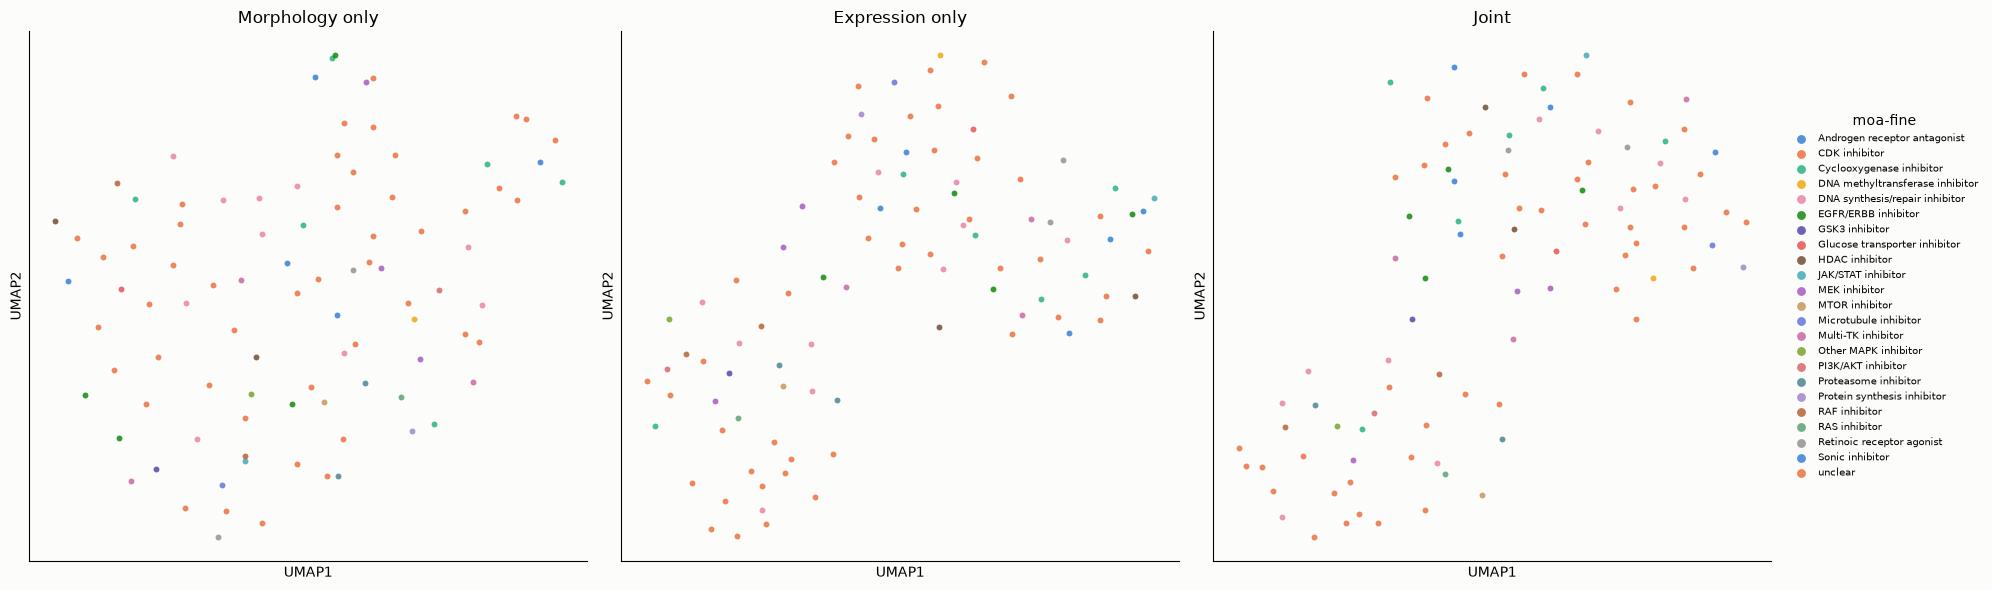

In [16]:
def embed(X: np.ndarray, seed: int = RANDOM_STATE) -> ad.AnnData:
    a = ad.AnnData(X=X.astype(np.float32))
    sc.pp.neighbors(a, use_rep="X", random_state=seed)
    sc.tl.umap(a, random_state=seed)
    return a


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_umap(ax, xy, labels, title, cmap):
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=18, alpha=0.8, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)


moa_labels = moa_shared.to_numpy()
cmap = color_map(moa_labels)

embeddings = {
    "Morphology only": embed(morph_z.to_numpy()),
    "Expression only": embed(rna_z.to_numpy()),
    "Joint": embed(joint_z),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, a) in zip(axes, embeddings.items()):
    plot_umap(ax, a.obsm["X_umap"], moa_labels, title, cmap)
axes[-1].legend(
    markerscale=1.5, fontsize=7, frameon=False, loc="center left",
    bbox_to_anchor=(1.02, 0.5), title="moa-fine",
)
fig.tight_layout()
plt.show()


### What drives PC1 of the expression embedding?

Same check as the HepG2 notebook: which genes load PC1, and which drugs sit
at its poles.


In [17]:
pc1_loadings = pd.Series(rna.varm["PCs"][:, 0], index=rna.var_names)

print("Top genes on one pole of PC1:")
print(pc1_loadings.sort_values().head(10))
print("\nTop genes on the other pole of PC1:")
print(pc1_loadings.sort_values(ascending=False).head(10))

drug_pc1 = rna_compound_pca[0].sort_values()
print("\nMost negative-PC1 drugs:")
print(drug_pc1.head(6))
print("\nMost positive-PC1 drugs:")
print(drug_pc1.tail(6))


Top genes on one pole of PC1:
gene_symbol
USP3      -0.109642
FTL       -0.107307
NUP58     -0.100173
WDR43     -0.096586
BHLHE40   -0.074445
IARS1     -0.062119
MDM2      -0.059568
UPP1      -0.057902
PDK1      -0.054903
TOP2A     -0.052128
dtype: float64

Top genes on the other pole of PC1:
gene_symbol
PAPPA      0.212457
KYNU       0.199368
PHLDB2     0.198993
IGFBP3     0.189497
EFNA5      0.170813
PITPNC1    0.165154
PARP14     0.149361
AADACP1    0.142823
CYP24A1    0.140370
STC1       0.137413
dtype: float64

Most negative-PC1 drugs:
drug
Dinaciclib          -4.240649
Homoharringtonine   -2.788198
Belinostat          -2.711401
Mebendazole         -2.354025
Decitabine          -1.899693
Malotilate          -1.779199
Name: 0, dtype: float32

Most positive-PC1 drugs:
drug
Amsacrine      1.731241
Irinotecan     1.755594
Busulfan       1.890299
Rimonabant     1.925246
Anastrozole    1.992437
Furosemide     2.259019
Name: 0, dtype: float32


## 12. Export paired h5ad files

Restricted to the compounds present in both modalities (the same 94 from
section 10 - a perfect match, so this is all 94 `a549_cells.h5ad` drugs),
each carrying `Metadata_Drug` / `Metadata_moa_fine` so they can be joined by
compound identity downstream:

- `lincs_morphology_a549_batch1.h5ad`: `X` = the Level 4b (normalized,
  feature-selected) well-level batch1 profiles built in section 3, one row
  per well.
- `lincs_morphology_a549_batch1_consensus.h5ad`: `X` = the Level 5
  compound-dose consensus profiles built in section 6, one row per
  (compound, dose).
- `lincs_expression_a549.h5ad`: every cell from `a549_cells.h5ad` treated
  with one of the shared compounds, `X` = the normalized/log1p expression
  from section 8 (all genes; `var["highly_variable"]` flags the 2000 used
  for PCA).


In [18]:
# drug_to_pert_id_batch1 maps a549_cells.h5ad's Title-Case drug names to morphology's
# Metadata_pert_id; reverse it to relabel morphology rows with the a549 name.
pert_id_to_drug_batch1 = {pid: d for d, pid in drug_to_pert_id_batch1.items() if pid is not None}

level4b_export = level4b_batch1.copy()
level4b_export["Metadata_pert_id"] = level4b_export["Metadata_broad_sample"].apply(short_broad_id)
level4b_export["Metadata_Drug"] = level4b_export["Metadata_pert_id"].map(pert_id_to_drug_batch1)
level4b_export = level4b_export[level4b_export["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
level4b_export["Metadata_moa_fine"] = level4b_export["Metadata_Drug"].map(moa_by_drug).astype(str)
level4b_meta_cols = [c for c in level4b_export.columns if c.startswith("Metadata_")]

morph_well_adata = ad.AnnData(
    X=level4b_export[morph_feature_cols_batch1].to_numpy(dtype=np.float32),
    obs=level4b_export[level4b_meta_cols].reset_index(drop=True),
    var=pd.DataFrame(index=morph_feature_cols_batch1),
)
morph_well_adata.write_h5ad("lincs_morphology_a549_batch1.h5ad")
print(f"lincs_morphology_a549_batch1.h5ad: {morph_well_adata.shape}, "
      f"{morph_well_adata.obs['Metadata_Drug'].nunique()} compounds")

consensus_export = consensus_batch1.copy()
consensus_export["Metadata_Drug"] = consensus_export["Metadata_pert_id"].map(pert_id_to_drug_batch1)
consensus_export = consensus_export[consensus_export["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
consensus_export["Metadata_moa_fine"] = consensus_export["Metadata_Drug"].map(moa_by_drug).astype(str)
consensus_meta_cols = [c for c in consensus_export.columns if c.startswith("Metadata_")]

morph_consensus_adata = ad.AnnData(
    X=consensus_export[morph_feature_cols_batch1].to_numpy(dtype=np.float32),
    obs=consensus_export[consensus_meta_cols].reset_index(drop=True),
    var=pd.DataFrame(index=morph_feature_cols_batch1),
)
morph_consensus_adata.write_h5ad("lincs_morphology_a549_batch1_consensus.h5ad")
print(f"lincs_morphology_a549_batch1_consensus.h5ad: {morph_consensus_adata.shape}, "
      f"{morph_consensus_adata.obs['Metadata_Drug'].nunique()} compounds")

lincs_morphology_a549_batch1.h5ad: (2772, 615), 94 compounds
lincs_morphology_a549_batch1_consensus.h5ad: (564, 615), 94 compounds


In [19]:
expression_export = rna[rna.obs["drug"].isin(shared_compounds)].copy()
expression_export.obs = expression_export.obs.rename(columns={"drug": "Metadata_Drug", "moa-fine": "Metadata_moa_fine"})
expression_export.write_h5ad("lincs_expression_a549.h5ad")

print(f"lincs_expression_a549.h5ad: {expression_export.shape}, "
      f"{expression_export.obs['Metadata_Drug'].nunique()} compounds")

well_drugs = set(morph_well_adata.obs["Metadata_Drug"])
consensus_drugs = set(morph_consensus_adata.obs["Metadata_Drug"])
expr_drugs = set(expression_export.obs["Metadata_Drug"])
print(f"\nSame compound set in all three exported files: {well_drugs == consensus_drugs == expr_drugs}")


lincs_expression_a549.h5ad: (605940, 62710), 94 compounds

Same compound set in all three exported files: True


## 13. Summary

- **Data recovery**: `LINCS/morphology/profiles/` (levels 3/4a/4b) and
  `LINCS/morphology/consensus/` (level 5) were `dvc`/`git-lfs` pointers, not
  actual data, in this environment. Levels 3/4a/4b were recovered from the
  public Cell Painting Gallery S3 mirror (`cpg0004-lincs`, unauthenticated);
  level 5 was recovered from GitHub's public LFS media endpoint and
  checksum-verified against each pointer file's `sha256`/`size` before
  overwriting the stub.
- **Level 3 -> 4a -> 4b -> 5 reconstruction (batch1, 136 plates, 52,223
  wells)**: our Level 4a reproduces Broad's official file almost exactly
  (median per-feature r ~ 1.0); our pooled-batch Level 4b feature selection
  overlaps Broad's per-plate selection 400/493 (~81%, with the gap explained
  by pooling all plates before selecting rather than per-plate); our
  mean-based Level 5 reproduces Broad's official MODZ consensus with median
  per-profile r ~ 1.0.
- **QC**: 37.4% percent replicating overall at the well level (34.9% low
  dose -> 41.5% high dose), well below HepG2's 69-91% because this library
  spans many ineffective doses of ~1500 compounds rather than a curated
  bioactives-at-effective-dose panel.
- **94/94** `a549_cells.h5ad` drugs matched to batch1 morphology - a
  perfect match, via PubChem CID chemical identity against this repo's own
  Drug Repurposing Hub reference (`repurposing_info.tsv`, see section 7)
  rather than name matching (fixed from a prior 86/94: case-insensitive
  `Metadata_pert_iname` name matching missed cases like `Furosemide`, whose
  molecule is registered under two different PubChem CIDs across sources,
  and `Bestatin` vs. the Hub's `ubenimex`, which don't share any name at
  all). Unlike the HepG2 notebook (119/120, one pre-existing gap), this one
  now has zero gaps: all three exported files carry exactly the same
  94-compound set.
- **Cross-modal agreement: Mantel r = 0.278, permutation p = 0.002** (999
  permutations, 94 shared compounds) - directionally consistent with
  HepG2's r=0.334, p=0.001. `moa-fine` silhouette is again negative in every
  space (morphology -0.28, expression -0.18, joint -0.18, on the 84/94
  shared compounds whose MoA class has >=2 members): neither modality
  cleanly separates the 23 literature MoA classes on its own here either.
- Gene expression PC1 again isolates a general cytotoxic-stress axis
  (MDM2/TOP2A vs. IGFBP3/PAPPA), with the same kind of compounds at its
  stressed pole (Dinaciclib, Homoharringtonine, Belinostat, Decitabine) as
  HepG2's heat-shock axis flagged - a different specific stress program, the
  same qualitative story: broadly cytotoxic drugs share a transcriptional
  signature that cuts across the literature MoA labels.
